# Determining Trade Union Status
### By: Christopher Hinton

### I will start by importing general libraries needed for the project.

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import math

#### Next I will import the training data.

In [2]:
df = pd.read_csv("Christopher-Train.csv")
print(df.shape)
df.head()

(1000, 21)


,ID,gender,Management,USAcitizen,Married,MonthsInUnion,ContinuingEd,FeatureA,Connectivity,FeatureC,...,FeatureE,FeatureF,FeatureG,FeatureB,DuesFrequency,PaperlessBilling,PaymentMethod,MonthlyDues,TotalDues,LeftUnion
0,CHRISTOPHER1,Female,0,Yes,No,32,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Bank transfer (automatic),84,2586,Yes
1,CHRISTOPHER2,Male,0,Yes,Yes,2,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),90,186,Yes
2,CHRISTOPHER3,Male,0,No,No,48,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),79,3772,No
3,CHRISTOPHER4,Male,0,Yes,Yes,59,Yes,No,Dial-in,Maryville,...,Maryville,Maryville,Maryville,Maryville,Two year,No,Credit card (automatic),19,1193,No
4,CHRISTOPHER5,Male,0,No,No,10,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),55,568,No


#### Next we want to drop any duplicate data points

In [3]:
#drop duplicates
df = df.drop_duplicates()
df.head()

,ID,gender,Management,USAcitizen,Married,MonthsInUnion,ContinuingEd,FeatureA,Connectivity,FeatureC,...,FeatureE,FeatureF,FeatureG,FeatureB,DuesFrequency,PaperlessBilling,PaymentMethod,MonthlyDues,TotalDues,LeftUnion
0,CHRISTOPHER1,Female,0,Yes,No,32,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Bank transfer (automatic),84,2586,Yes
1,CHRISTOPHER2,Male,0,Yes,Yes,2,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),90,186,Yes
2,CHRISTOPHER3,Male,0,No,No,48,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),79,3772,No
3,CHRISTOPHER4,Male,0,Yes,Yes,59,Yes,No,Dial-in,Maryville,...,Maryville,Maryville,Maryville,Maryville,Two year,No,Credit card (automatic),19,1193,No
4,CHRISTOPHER5,Male,0,No,No,10,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),55,568,No


#### Below we will drop unuseful columns.

In [4]:
#drop unuseful columns
df = df.drop(columns= df.loc[:,"FeatureA":"FeatureB"])
print(df.shape)
df.head()

(1000, 13)


,ID,gender,Management,USAcitizen,Married,MonthsInUnion,ContinuingEd,DuesFrequency,PaperlessBilling,PaymentMethod,MonthlyDues,TotalDues,LeftUnion
0,CHRISTOPHER1,Female,0,Yes,No,32,Yes,Month-to-month,No,Bank transfer (automatic),84,2586,Yes
1,CHRISTOPHER2,Male,0,Yes,Yes,2,Yes,Month-to-month,Yes,Bank transfer (automatic),90,186,Yes
2,CHRISTOPHER3,Male,0,No,No,48,Yes,Two year,No,Credit card (automatic),79,3772,No
3,CHRISTOPHER4,Male,0,Yes,Yes,59,Yes,Two year,No,Credit card (automatic),19,1193,No
4,CHRISTOPHER5,Male,0,No,No,10,Yes,Month-to-month,Yes,Credit card (automatic),55,568,No


#### There were unuseable values found in the 'TotalDues' column that need to be removed.  As well, it was noted that the 'TotalDues' column is populated with string values, they will need to be converted to integer values before they can be used. 

In [5]:
# Replace non-numerical values from "TotalDues" column with 0
df['TotalDues'] = df['TotalDues'].str.replace('[^0-9]', '0')

# Convert totaldues from string values to integer values
dues = df.loc[:, "TotalDues"].values

for i in range(len(dues)):
    dues[i] = int(dues[i])



C:\Users\cdhin\AppData\Local\Temp\ipykernel_25740\3889968323.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  df['TotalDues'] = df['TotalDues'].str.replace('[^0-9]', '0')


#### Now we need to find and handle outliers. I'll create three boxplots to check for outliers in columns: TotalDues, MonthlyDues, and MonthsInUnion. 

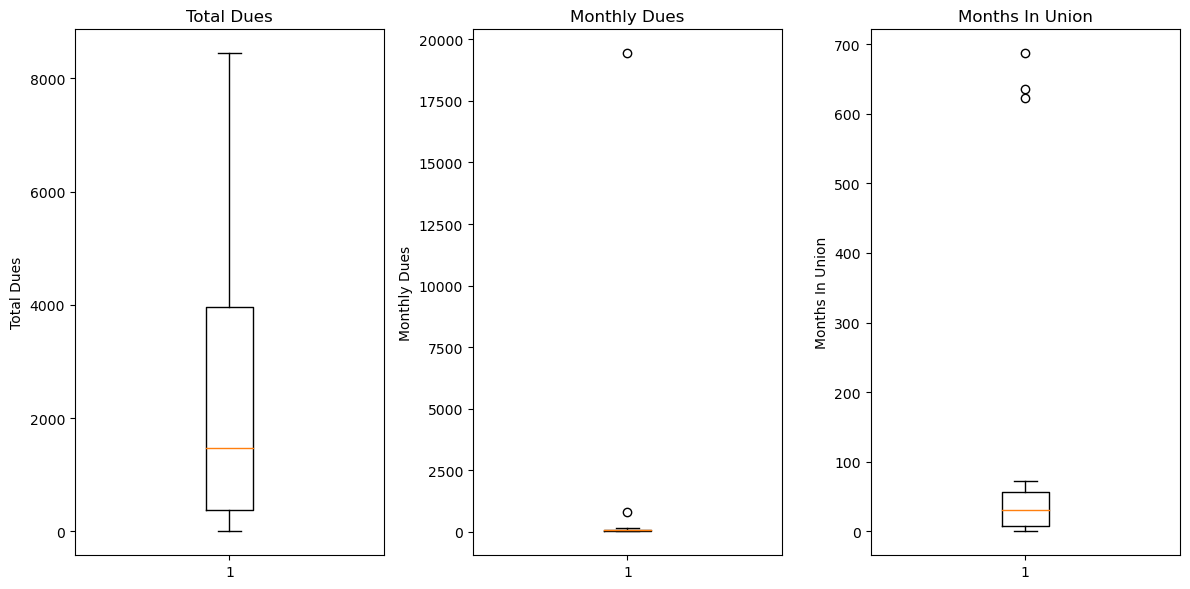

In [6]:
# Boxplot for TotalDues
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=[12,6])

#plt.subplot(3,1,1)
#ax1.boxplot([df[df['Management'] == 1]['TotalDues'], 
             #df[df['Management'] == 0]['TotalDues']], 
             #labels=["Yes", "No"])
ax1.boxplot(df["TotalDues"])
ax1.set_ylabel("Total Dues")
ax1.set_title("Total Dues")
#plt.show()

#plt.subplot(3,1,2)
# Boxplot for MonthlyDues

#ax2.boxplot([df[df['Management'] == 1]['MonthlyDues'], 
             #df[df['Management'] == 0]['MonthlyDues']], 
             #labels=["Yes", "No"])
ax2.boxplot(df['MonthlyDues'])
ax2.set_ylabel("Monthly Dues")
ax2.set_title("Monthly Dues")
#plt.show()

#plt.subplot(3,1,3)
# Boxplot for MonthsInUnion

#ax3.boxplot([df[df['Management'] == 1]['MonthsInUnion'], 
             #df[df['Management'] == 0]['MonthsInUnion']], 
             #labels=["Yes", "No"])
ax3.boxplot(df['MonthsInUnion'])
ax3.set_ylabel("Months In Union")
ax3.set_title("Months In Union")
plt.tight_layout()
plt.show()

#### After looking at all three boxplots there appears to be 3 outliers in the dataset. For a deeper analysis, next we'll find the z-scores and remove all z-scores with an absolute values greater than 3. 

In [7]:
# Calculate z-score
def calc_zscore(data):
    # Calculate the mean and standard deviation
    mean = np.mean(data)
    std_dev = np.std(data)

    # Calculate the z-scores for each data point
    z_scores = [(x - mean) / std_dev for x in data]
    return z_scores

In [8]:
# Convert "MonthsInUnion" to z-score
df['MonthsInUnion_zscore'] = calc_zscore(df['MonthsInUnion'])

# Convert "MonthlyDues" to z-score
df['MonthlyDues_zscore'] = calc_zscore(df['MonthlyDues'])

# Convert "TotalDues" to z-score
df['TotalDues_zscore'] = calc_zscore(df['TotalDues'])

print(np.where(np.abs(df['TotalDues_zscore']) > 3))
print(np.where(np.abs(df['MonthlyDues_zscore']) > 3))
print(np.where(np.abs(df['MonthsInUnion_zscore']) > 3))

(array([], dtype=int64),)
(array([14], dtype=int64),)
(array([ 14, 485, 753], dtype=int64),)


#### I choose to remove members with MonthsInUnion_zscore higher than 3.  I did this because those three members encompasses all outliers in the other two columns as well. 

In [9]:
# Remove high z-score columns
print("DataFrame Shape before removing high z-scores", df.shape)
df.drop(df[df["MonthsInUnion_zscore"] > 3].index, inplace=True)
print("DataFrame Shape after removing high z-scores", df.shape)

DataFrame Shape before removing high z-scores (1000, 16)
DataFrame Shape after removing high z-scores (997, 16)


#### Below is a scatter plot using MonthsInUnion and MonthlyDues. We can see there are no longer any outliers in our data.

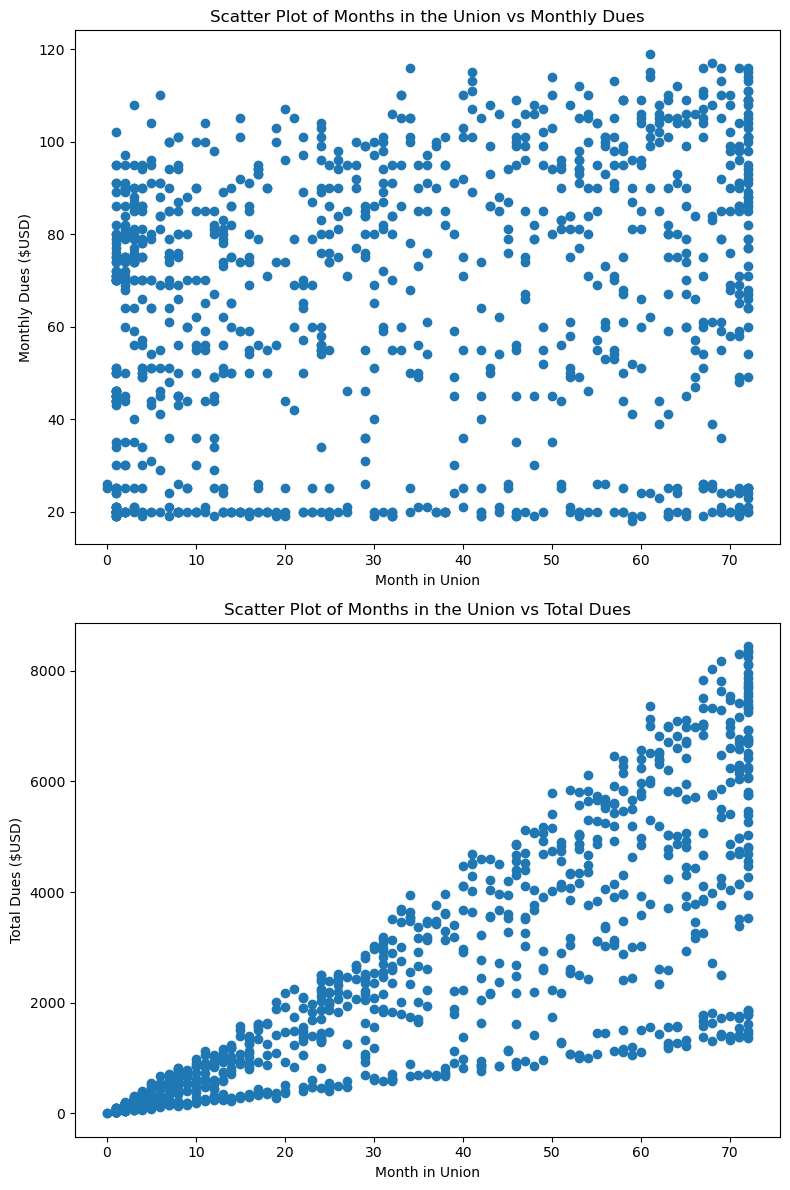

In [10]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=[8,12])
ax1.scatter(x=df["MonthsInUnion"], y=df["MonthlyDues"])
ax1.set_title("Scatter Plot of Months in the Union vs Monthly Dues")
ax1.set_xlabel("Month in Union")
ax1.set_ylabel("Monthly Dues ($USD)")

ax2.scatter(x=df["MonthsInUnion"], y=df["TotalDues"])
ax2.set_title("Scatter Plot of Months in the Union vs Total Dues")
ax2.set_xlabel("Month in Union")
ax2.set_ylabel("Total Dues ($USD)")

plt.tight_layout()
plt.show()



#### When we compare TotalDues to MonthsInUnion using a scatter plot we can see a somewhat linear correalation.  Which once again is a good indication that all outliers have been removed.

### Before building any models we will first need to encode the categorical data. This should remove all string variables from the data and allow our models to function appropriately. 

### OneHotEncode with dummy variables

In [11]:
dummy_df = pd.get_dummies(data=df, columns=["gender","Management","USAcitizen",
                      "Married","ContinuingEd",
                      "DuesFrequency","PaperlessBilling",
                      "PaymentMethod","LeftUnion"])

print(dummy_df.columns,'\nEncoded DataFrame Shape:', dummy_df.shape)

Index(['ID', 'MonthsInUnion', 'MonthlyDues', 'TotalDues',
       'MonthsInUnion_zscore', 'MonthlyDues_zscore', 'TotalDues_zscore',
       'gender_Female', 'gender_Male', 'Management_0', 'Management_1',
       'USAcitizen_No', 'USAcitizen_Yes', 'Married_No', 'Married_Yes',
       'ContinuingEd_No', 'ContinuingEd_Yes', 'DuesFrequency_Month-to-month',
       'DuesFrequency_One year', 'DuesFrequency_Two year',
       'PaperlessBilling_No', 'PaperlessBilling_Yes',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'LeftUnion_No', 'LeftUnion_Yes'],
      dtype='object') 
Encoded DataFrame Shape: (997, 28)


### Below is a Hexbin Plot of the some key features.

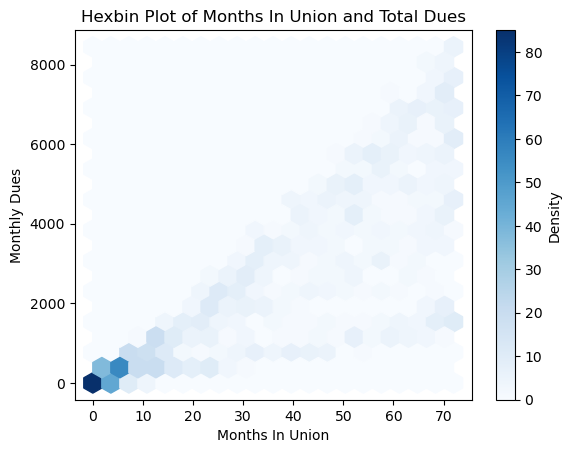

In [12]:
plt.hexbin(dummy_df['MonthsInUnion'], dummy_df['TotalDues'], gridsize=20, cmap='Blues')
plt.xlabel('Months In Union')
plt.ylabel('Monthly Dues')
plt.title('Hexbin Plot of Months In Union and Total Dues')
plt.colorbar(label='Density')
plt.show()

### Below we'll perform a Principal Component Analysis on our dataset.  Then attempt to reduce the number of dimensions.

In [13]:
# Import needed libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data_to_scale = dummy_df.loc[:, 'MonthsInUnion':'PaymentMethod_Mailed check']
scaler = StandardScaler()
scaler.fit(data_to_scale)
scaler.set_output(transform='pandas')
scaled_data = scaler.transform(data_to_scale)

pca = PCA(n_components=25)
pca.fit(scaled_data)

x_pca = pca.transform(scaled_data)
print(f'Scaled shape: {scaled_data.shape}')


Scaled shape: (997, 25)


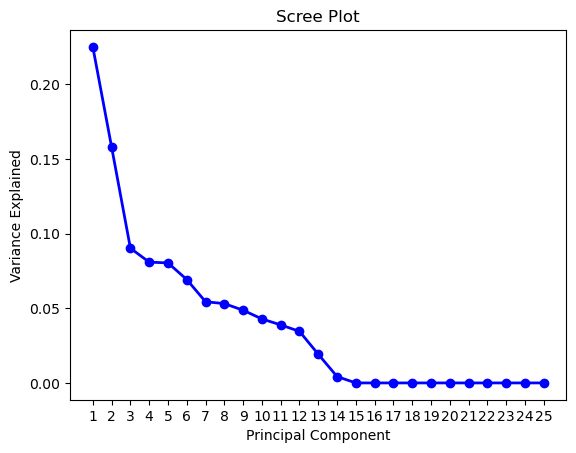

In [14]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.xticks(list(range(1,26,1)))
plt.ylabel('Variance Explained')
plt.show()

In [15]:
top2 = sum(pca.explained_variance_ratio_[:2])
top5 = sum(pca.explained_variance_ratio_[:5])
top10 = sum(pca.explained_variance_ratio_[:10])
top14 = sum(pca.explained_variance_ratio_[:14])
my_list = list(range(1,26,1))
df_comps = pd.DataFrame(pca.components_,columns=data_to_scale.columns,index = [my_list])

print(f"""
From the Scree Plot: 
The top 2 components account for {int(top2 * 100)}% of the variance.
The top 5 components account for {int(top5 * 100)}% of the variance.
The top 10 components account for {int(top10 * 100)}% of the variance.
The top 14 components account for {int(top14 * 100)}% of the variance.

""")



From the Scree Plot: 
The top 2 components account for 38% of the variance.
The top 5 components account for 63% of the variance.
The top 10 components account for 90% of the variance.
The top 14 components account for 100% of the variance.




Based on the PCA and Scree plot to use 10 principle components in order to account for 90% of the variance and the top 14 accounts for 100% variance.  I determined that using the top 14 components is all that is needed. So we will use the top 14 for our modeling. 

In [16]:
pca_final = PCA(n_components=14)
pca_final.fit(scaled_data)

x_pca_final = pca_final.transform(scaled_data)

y = dummy_df.loc[:, 'LeftUnion_Yes']
print(f'X shape: {x_pca_final.shape},  y shape: {y.shape}')

X shape: (997, 14),  y shape: (997,)


### Next we will plot some key features from our PCA performed above.

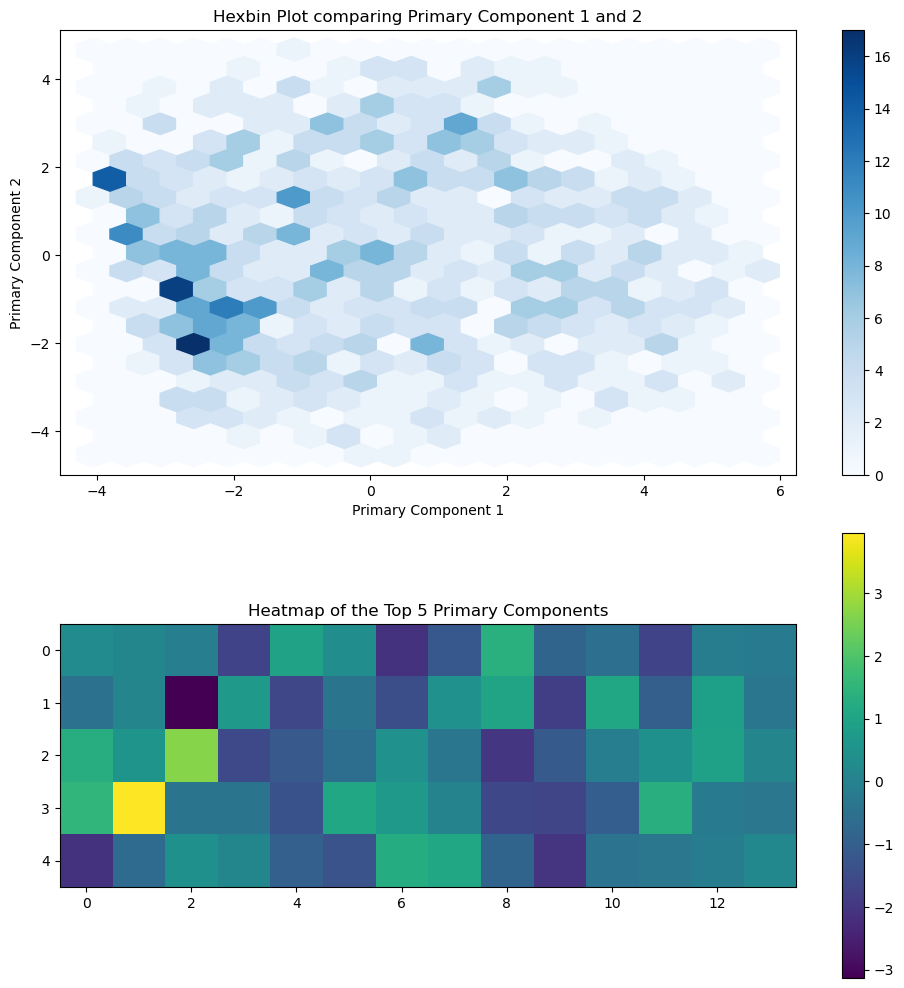

In [17]:
# Create a dataframe to use in plot
pca_df = pd.DataFrame(data = x_pca_final)
pca_df.head()

# Plot
plt.figure(figsize=[10,10])
plt.subplot(2,1,1)
plt.hexbin(pca_df[0], pca_df[1], gridsize=20, cmap='Blues')
plt.xlabel('Primary Component 1')
plt.ylabel('Primary Component 2')
plt.title('Hexbin Plot comparing Primary Component 1 and 2')
plt.colorbar()

plt.subplot(2,1,2)
plt.imshow(pca_df[:5], cmap='viridis')
plt.colorbar()
plt.title('Heatmap of the Top 5 Primary Components')

plt.tight_layout()
plt.show()

## We will look at 3 different models and select the one which gives us the best accuracy. 
### First we need to split our PCA final data into training, validation, and testing subsets.

In [18]:
X_train, X_hold, y_train, y_hold = train_test_split(
    x_pca_final, y, test_size=0.3, random_state=1, stratify=y)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_hold, y_hold, test_size=0.5, random_state=1, stratify=y_hold)
print(f"""Training Features Shape: {X_train.shape}
Validation Features Shape: {X_valid.shape}
Test Features Shape: {X_test.shape}""")

Training Features Shape: (697, 14)
Validation Features Shape: (150, 14)
Test Features Shape: (150, 14)


### Below is a Linear Regression model.

In [19]:
# Import libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix

# Create model
reg_mod = LinearRegression().fit(X_train, y_train)

# Calculate the r-squared score of the training and validation values.

# Training data
reg_mod.fit(X_train, y_train)
y_train_pred = reg_mod.predict(X_train)
r2_training = r2_score(y_train, y_train_pred)

# Validation data
reg_mod.fit(X_valid, y_valid)
y_valid_pred = reg_mod.predict(X_valid)
r2_valid = r2_score(y_valid, y_valid_pred)
mse = mean_squared_error(y_valid, y_valid_pred)

print(f"""
Training r-Squared: {r2_training * 100:.2f}%
Validation r-Squared: {r2_valid * 100:.2f}%
""")



Training r-Squared: 25.50%
Validation r-Squared: 36.96%



#### As shown above the Linear Regression model performed very poorly as a predictor in this case. Scoring a r-square score of just 36.96% accuracy on the validation data.

### Below is a Random Forrest model.

In [20]:
# Import libraries
from sklearn.ensemble import RandomForestClassifier
# Create 2 lists to hold accuracy calculations for training and validation datasets.
rf_train_acc = [] 
rf_valid_acc = []

depth_range = range(2, 31)

for depth in depth_range:
    np.random.seed(1)
    
    temp_forest = RandomForestClassifier(max_depth=depth, 
                                         n_estimators=100)
    temp_forest.fit(X_train, y_train)
    
    rf_train_acc.append(temp_forest.score(X_train, y_train))
    rf_valid_acc.append(temp_forest.score(X_valid, y_valid))
    
rf_idx = np.argmax(rf_valid_acc)
rf_opt_depth = depth_range[rf_idx]

opt_train_acc = rf_train_acc[rf_idx]
opt_valid_acc = rf_valid_acc[rf_idx]

print(f"""Optimal value for max_depth:           {rf_opt_depth}
Training Accuracy for Optimal Model:   {opt_train_acc * 100:.2f}%
Validation Accuracy for Optimal Model: {opt_valid_acc * 100:.2f}%
""")

Optimal value for max_depth:           13
Training Accuracy for Optimal Model:   99.57%
Validation Accuracy for Optimal Model: 80.67%



#### As shown above the Random Forest model performed much better than the Linear Regression model as a predictor. Scoring a accuracy score of 80.67% accuracy on the validation data.

### Below is a Support Vector model.

In [21]:
# Import Libraries
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create and fit the model
svm_mod = SVC(kernel='linear', C=1.0, gamma='auto') 
svm_mod.fit(X_train, y_train)

# Make prediction based on validation data
y_valid_pred = svm_mod.predict(X_valid)

# Evaluate model performance
svm_acc = accuracy_score(y_valid, y_valid_pred)
print(f"""
SVM Accuracy: 
{svm_acc * 100:.2f}%
SVM Classification Report: 
{classification_report(y_valid, y_valid_pred)}
SVM Confusion Matrix: 
{confusion_matrix(y_valid, y_valid_pred)}
""")


SVM Accuracy: 
82.00%
SVM Classification Report: 
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       110
           1       0.70      0.57      0.63        40

    accuracy                           0.82       150
   macro avg       0.78      0.74      0.76       150
weighted avg       0.81      0.82      0.81       150

SVM Confusion Matrix: 
[[100  10]
 [ 17  23]]



#### As shown above the Support Vector model performed slight better than the Random Forest model as a predictor. Scoring a accuracy score of 82.00% accuracy on the validation data.

### We will now run our test data through the SVM, as our choosen model.

In [22]:
y_test_pred = svm_mod.predict(X_test)

# Evaluate model performance
svm_final_acc = accuracy_score(y_test, y_test_pred)

print(f"""
Accuracy of our Final SVM: 
{svm_final_acc * 100:.2f}%
""")


Accuracy of our Final SVM: 
78.67%



## Conclusion: 
The best model for this project appears to be a Support Vector Model.  The primary rationale being its accuracy score being about 1.4% better than the Random Forest model.  Though it should be noted that if the data subsets were changed from 70/15/15 to 65/17.5/17.5, the RF's accuracy wnt up to 81.03%, while the SVM's accuracy went down to 79.31%.  Many other data subsets splits were tested, however, the 65/17.5/17.5 was the only split that changed the overall accuracy ranking amoung these three models.  Using our SVM as the final model we can see an accuracy score of 78.67% using the test data.  